In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

insurance = pd.read_csv('insurance.csv')

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
               age          bmi     children       charges
count  1338.000000  1338.000000  1338

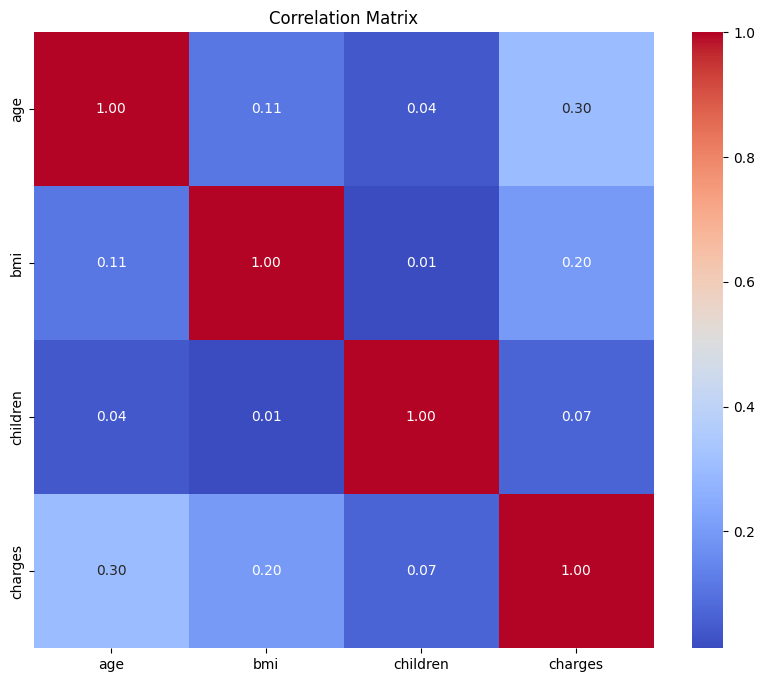

In [4]:
print(insurance.head())
insurance.info()
print(insurance.describe())

corr = insurance.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

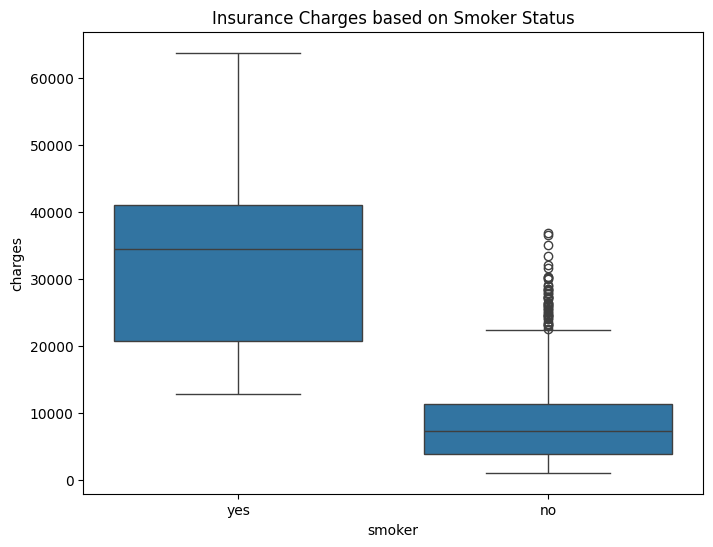

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=insurance)
plt.title("Insurance Charges based on Smoker Status")
plt.show()

insurance_encoded = pd.get_dummies(insurance, drop_first=True)

X = insurance_encoded.drop('charges', axis=1)
y = insurance_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
results = {}

# 1. Multiple Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results['Multiple Linear Regression'] = r2_score(y_test, lr_pred)

# 2. Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)
poly_pred = poly_lr.predict(X_test_poly)
results['Polynomial Regression'] = r2_score(y_test, poly_pred)

# 3. Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
results['Decision Tree'] = r2_score(y_test, dt_pred)

# 4. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = r2_score(y_test, rf_pred)

# 5. Support Vector Machine (SVR)
svm = SVR(kernel='rbf', C=10000)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
results['SVM'] = r2_score(y_test, svm_pred)

# Display Comparative R-squared Results
print("Model R-squared Scores:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

Model R-squared Scores:
Multiple Linear Regression: 0.7836
Polynomial Regression: 0.8666
Decision Tree: 0.7266
Random Forest: 0.8651
SVM: 0.8537
